<a href="https://colab.research.google.com/github/dr-bankert-augustana/PHYS_200/blob/main/phy_200_lesson_2_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a name="Notebook-Start"></a>

---

<font size = 7> <b> Lesson 2.2 (Linear Regression) </b> </font>

---

<font size = 5> <b> Notebook Index </b> </font>

1.  [Learning Outcomes](#Learning-Outcomes)

2.  [Introduction](#Introduction)

3.  [Import Python Libraries](#Import-Python-Libraries)

4.  [Define Useful Functions](#Define-Useful-Functions)

5.  [Load The First Dataset](#Load-The-First-Dataset)

6.  [Least Squares Linear Regression](#Least-Squares-Linear-Regression)

7.  [Implementing Least Squares Linear Regression](#Implementing-LSLR)

8.  [Introducing The Sklearn LinearRegression Function](#Introducing-Sklearn-LinearRegression)

9.  [A New Dataset: Now With Initial Velocity](#Initial-Velocity-Dataset)

10. [Multivariate Linear Regression](#Multivariate-Linear-Regression)

11. [Multiple Target Multivariate Linear Regression](#Multiple-Targets)

12. [Lesson Summary](#Lesson-Summary)

13. [Appendix A: New Term Definitions](#Appendix-Definitions)

14. [Appendix B: Derivation Of Least Squares Linear Regression](#Appendix-LSLR-Derivation)
$
\newcommand{\parens}[1]{\left( #1 \right)}
\newcommand{\brackets}[1]{\left[ #1 \right]}
\newcommand{\lsum}{\displaystyle \sum\limits_{i=1}^{N}}
\newcommand{\parens}[1]{\left(#1\right)}
\newcommand{\dsfrac}[2]{\displaystyle\frac{#1}{#2}}
\newcommand{\dpfrac}[2]{\displaystyle\parens{\frac{#1}{#2}}}
\newcommand{\parderiv}[2]{\dsfrac{\partial #1}{\partial #2}}
\newcommand{\spc}{\hspace{0.1 pc}}
\newcommand{\ra}{\Rightarrow}
\newcommand{\of}[1]{{\scriptsize (#1)}}
\newcommand{\rule}{\Huge \hspace{-0.2 pc} \displaystyle\frac{\hspace{20 pc}}{\hspace{20 pc}}}
\newcommand{\mps}{\spc \frac{\textrm{m}}{\textrm{s}}}
\newcommand{\mpss}{\spc \frac{\textrm{m}}{\textrm{s}^2}}
\newcommand{\twomatrixtall}[2]{
\left( \begin{array}{c} #1 \\ #2 \end{array} \right)
}
\newcommand{\fourmatrixsquare}[4]{
\left( \begin{array}{c c} #1 & #2 \\ #3 & #4 \end{array} \right)
}
\newcommand{\fourmatrixlong}[4]{
\left( \begin{array}{c c c c} #1 & #2 & #3 & #4 \end{array} \right)
}
$

<a name="Learning-Outcomes"></a>

---

<font size = 6> <b> 1. Learning Outcomes </b> </font>

---

<font size = 5> <b> Learning Outcomes: </b> </font>

By the end of this lesson, students will be able to:

  1. Explain the principles of [linear regression](#Definition-Linear-Regression) and the formulas for computing [least squares linear regression](#Definition-LSLR) (LSLR).

  2. Interpret the components of a linear regression model (coefficients and bias) in mathematical and real-world terms.

  3. Apply the LSLR method to compute model parameters and understand how it minimizes prediction error.

  4. Build and evaluate regression models using scikit-learn's `LinearRegression` and `mean_squared_error` tools.

  5. Model physical systems such as free fall and inelastic collisions, and explain how regression reflects underlying physical laws.

  6. Use [multivariate linear regression](#Definition-Multi-Linear-Regression) to construct and interpret models using multiple input features to improve predictive performance and capture complex relationships.

  7. Use [multi-target multivariate linear regression](#Definition-Multi-Target) to model multiple target variables simultaneously, and interpret the learned coefficients.

[Return to Top](#Notebook-Start)

<a name="Introduction"></a>

---

<font size = 6> <b> 2. Introduction </b> </font>

---

<font size = 5> <b> 2.1 What Is Linear Regression? </b> </font>

In the last lesson, we learned how to build simple linear models by examining a system, defining what we want to understand about the system (the target), choosing which aspects of the system to include (the features), and then approximating their relationship with a straight line. We then learned how to refine our model by manually adjusting the model's linear coefficient and bias to minimize the loss (as measured by the root mean squared error function).

<br>

In this lesson, we introduce a more systematic, mathematical approach to model refinement called [linear regression](#Definition-Linear-Regression). Linear regression is a powerful technique that automates the linear coefficient and bias selection process and improves the accuracy and reliability of our models.

<center>$\rule$</center>

<font size = 5> <b> 2.2 What Does Linear Regression Do? </b> </font>

Previously, we guessed, checked, and adjusted our model's parameters to try to minimize loss. While this approach gave us a good sense of how the parameters affect the model, it's not a practical or reliable method for handling larger datasets or more complex models. [Linear regression](#Definition-Linear-Regression) replaces that guesswork with a rigorous mathematical approach. From the data, linear regression directly calculates the values of the model's linear coefficient and bias that minimize the loss function. In short, it finds the line of best-fit to the data automatically, without the need for manual tuning.

<center>$\rule$</center>

<font size = 5> <b> 2.3 Why Use Linear Regression? </b> </font>


[Linear regression](#Definition-Linear-Regression) improves on the guess-and-check approach in several important ways:

  * <b>Objective</b>: It removes guesswork by relying on a well-defined mathematical process.

  * <b>Reproducible</b>: Anyone using the same data and method will get the same results.

  * <b>Scalable</b>: It works efficiently on large datasets, making it practical for real-world applications.

  * <b>Predictive</b>: It builds reliable models that can make accurate predictions.

In short, linear regression takes what we've already learned and turns it into a more reliable, automated technique for building predictive models.

<center>$\rule$</center>

<font size = 5> <b>2.4 What Is The Core Idea Behind Linear Regression? </b> </font>

[Linear regression](#Definition-Linear-Regression) is built on a simple idea: if two variables are linearly related (meaning that as one variable changes, the other changes in a predictable, proportional way), we can describe their relationship with a straight line.

<br>

><b>Recall</b>: In a linear model, one variable is considered independent ($\large X$: the <b>feature</b> that we observe or control). The other variable is considered dependent ($\large y$: the <b>target</b> that we want to predict). The model outputs a <b>prediction</b> for the target variable ($\large \hat{y}_i$) for each input value of the feature variable(s) ($\large X_i$) using the formula:


<br>

<center>
<font size = 5>
 $\hat{y}_i = c \hspace{0.1 pc} X_i + b$
</font>
</center>

<br>

>* $\large c$ represents the <b>linear coefficient</b> (also called the 'slope' of the line), which tells us how much the target variable predictions $\large \hat{y}_i$ change for each unit change in the feature variable $\large X_i$.
* $\large b$ represents the <b>bias</b> (also called the 'y-intercept' of the line), which tells us the predicted value of the target variable $\large \hat{y}_i$ when the feature variable(s) $\large X_i = 0$.

<br>

The goal of linear regression is to find the values of $\large c$ and $\large b$ that result in a model that best-fits the observed data points by minimizing the difference between the model's predicted values and the actual data points. Later in this lesson, we discuss how we mathematically determine this "best fit".

<br>

><b>Note</b>: Linear regression is most effective when the relationship between variables is roughly linear. If the data curves or has more complex patterns, we may need to use more advanced modeling techniques. We explore some of these other techniques later in this lesson.

[Return to Top](#Notebook-Start)

<a name="Import-Python-Libraries"></a>

---

<font size = 6> <b> 3. Import Python Libraries </b> </font>

---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display_html
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

[Return to Top](#Notebook-Start)

<a name="Define-Useful-Functions"></a>

---

<font size = 6> <b> 4. Define Useful Functions </b> </font>

---

In [ ]:
#@title This cell defines the functions: load_model, display_dataframes, display_model, plot_data, rmse_loss.

##=============================================================================================##
## Included Functions:                                                                         ##
##                                                                                             ##
## 1. load_model         - Load and clean data from input file, split into feature and target  ##
## 2. display_dataframes - Display multiple DataFrames side-by-side with titles                ##
## 3. display_model      - Display models' parameters and loss in a DataFrame                  ##
## 4. plot_data          - Create a graph with raw data, can add model to graph if needed      ##
## 5. rmse_loss          - Implement the root mean squared error loss function                 ##
##=============================================================================================##

##=============================================================================================##
## Function:  load_model                                                                       ##
##                                                                                             ##
## Purpose:   Load and clean data from input file, split into feature and target               ##
##                                                                                             ##
## Input(s):  filename     - Name of the file containing the data                              ##
##            feature_list - List of column names containing feature data                      ##
##            target_list  - List of column names containing target data                       ##
##                                                                                             ##
## Output(s): features     - DataFrame containing model feature data                           ##
##            targets      - DataFrame containint model target data                            ##
##=============================================================================================##

def load_model(filename, feature_list, target_list):

  ##===========================================================================================##
  ## Load in the Full Data Set and Drop Any Rows Missing Data:                                 ##
  ##===========================================================================================##

  data = pd.read_csv(filename).dropna()

  ##===========================================================================================##
  ## Separate the Feature and Target Data and Drop Any Rows Missing Data:                      ##
  ##===========================================================================================##

  # Identify the feature data:

  features = pd.DataFrame(data[feature_list])

  # Identify the target data:

  targets = pd.DataFrame(data[target_list])

  # Display the feature and target data:

  display_dataframes([data, features, targets], ["Full Dataset", "Feature Data", "Target Data"])

  ##===========================================================================================##
  ## Return the Feature Data, and Target Data:                                                 ##
  ##===========================================================================================##

  return features, targets

##=============================================================================================##
## Function:  display_dataframes                                                               ##
##                                                                                             ##
## Purpose:   Display multiple DataFrames side-by-side with titles                             ##
##                                                                                             ##
## Input(s):  item_list  - List of DataFrames to be displayed                                  ##
##            title_list - List of titles for the displayed DataFrames                         ##
##                                                                                             ##
## Output(s): None                                                                             ##
##=============================================================================================##

def display_dataframes(item_list, title_list):

  ##===========================================================================================##
  ## Create a String for Housing the Commands to Be Sent to the display_html() Function:       ##
  ##===========================================================================================##

  html_str = ''

  ##===========================================================================================##
  ## Loop Over the Elements in the item_list and title_list:                                   ##
  ##===========================================================================================##

  for df, title in zip(item_list, title_list):

    ##=========================================================================================##
    ## Wrap title and DataFrames in a Styled HTML <div>:                                       ##
    ##=========================================================================================##

      html_str += f'''
      <div style="display: inline-block; margin-right: 20px; vertical-align: top;">
          <h3 style="text-align: center;">{title}</h3>
          {pd.DataFrame(df).head().to_html()}
      </div>
      '''

  ##===========================================================================================##
  ## Send the HTML String to the display_html() Function:                                      ##
  ##===========================================================================================##

  display_html(html_str, raw = True)

##=============================================================================================##
## Function:  display_model                                                                    ##
##                                                                                             ##
## Purpose:   Display models' parameters and loss in a DataFrame                               ##
##                                                                                             ##
## Input(s):  model_list - List of models' names to be displayed                               ##
##            coef_list  - List of models' coefficients to be displayed                        ##
##            bias_list  - List of models' bias to be displayed                                ##
##            loss_list  - List of models' loss to be displayed                                ##
##            title      - Title for the display of models                                     ##
##            truncation - Number of decimals to display for numbers (optional)                ##
##                                                                                             ##
## Output(s): None                                                                             ##
##=============================================================================================##

def display_model(model_list, coefficient_list, bias_list, loss_list, title, truncation = 3):

  ##===========================================================================================##
  ## Create a DataFrame to Hold the Results:                                                   ##
  ##===========================================================================================##

  results = pd.DataFrame()

  ##===========================================================================================##
  ## Round the Numeric Values to the Desired Level of Desired Truncation:                      ##
  ##===========================================================================================##

  # Round the coefficients:

  for i in range(len(coefficient_list)):

    coefficient_list[i] = np.round(coefficient_list[i], truncation)

  # Round the biases:

  for i in range(len(bias_list)):

    bias_list[i] = np.round(bias_list[i], truncation)

  # Round the losses:

  for i in range(len(loss_list)):

    loss_list[i] = np.round(loss_list[i], truncation)

  ##===========================================================================================##
  ## Add the Contents of the DataFrame Columns:                                                ##
  ##===========================================================================================##

  # Add the model names:

  results["Model"] = model_list

  # Add the model coefficients:

  results["Coefficient(s)"] = coefficient_list

  # Add the model biases:

  results["Bias(es)"] = bias_list

  # Add the model rmses:

  results["Loss"] = loss_list

  ##===========================================================================================##
  ## Index the Results DataFrame By Model Name:                                                ##
  ##===========================================================================================##

  results.set_index("Model", inplace = True)

  ##===========================================================================================##
  ## Display the Results DataFrame Using display_dataframes():                                 ##
  ##===========================================================================================##

  display_dataframes([results], [title])

##=============================================================================================##
## Function:  plot_data                                                                        ##
##                                                                                             ##
## Purpose:   Create a scatterplot with optional model overlays and error bands                ##
##                                                                                             ##
## Input(s):  x_data        - List of data points' x-axis values                               ##
##            y_data        - List of data points' y-axis values                               ##
##            title         - Graph title                                                      ##
##            axis_labels   - Override axis labels [x_label, y_label] (optional)               ##
##            model_list    - List of model predictions to overlay (optional)                  ##
##            color_list    - Colors for each model line (optional)                            ##
##            label_list    - Labels for each model line (optional)                            ##
##            error_display - Show +/- error band around first model (default is False)        ##
##            error         - Error value for shaded band (optional)                           ##
##                                                                                             ##
## Output(s): graph       - Matplotlib axes object, can be used for overplotting               ##
##=============================================================================================##

def plot_data(x_data, y_data, title, axis_labels = [], model_list = [], color_list = [],
              label_list = [], error_display = False, error = 0):

  ##===========================================================================================##
  ## Setup the Graph:                                                                          ##
  ##===========================================================================================##

  # Create the Matplotlib figure:

  figure = plt.figure(figsize = (12, 9))

  # Add a graph to the figure:

  graph = figure.add_subplot()

  # Set the graph background Color:

  graph.set_facecolor('lightcyan')

  # Set the graph title:

  graph.set_title(title, fontsize = 20)

  # Set the x_label and y_label:

  if (axis_labels != []):

    graph.set_xlabel(axis_labels[0], fontsize = 14)

    graph.set_ylabel(axis_labels[1], fontsize = 14)

  # Apply a grid to the graph:

  graph.grid(which = 'both')

  # Adjust the x-axis scale of the graph:

  graph.autoscale(enable = True, axis = 'x', tight = False)

  # Adjust the y-axis scale of the graph:

  graph.autoscale(enable = True, axis = 'y', tight = False)

  ##===========================================================================================##
  ## Add Data to the Graph:                                                                    ##
  ##===========================================================================================##

  # Create a scatterplot of the data:

  sns.scatterplot(x = x_data, y = y_data, ax = graph)

  # Overlay model predictions:

  for i in range(0, len(model_list)):

    graph.plot(x_data, model_list[i], color = color_list[i], label = label_list[i])

  ##===========================================================================================##
  ## If requested, show the +/- error bounds:                                                  ##
  ##===========================================================================================##

  if ((error_display == True) and model_list != []):

    # Create the error+ model:

    model_plus_error  = model_list[0].iloc[:, 0] + error

    # Create the error- model:

    model_minus_error = model_list[0].iloc[:, 0] - error

    # Store the error+ and error- models in a DataFrame and Sort by x_data values:

    error_df = pd.DataFrame({
        'X-Data': x_data,
        'Model+Error': model_plus_error,
        'Model-Error': model_minus_error
    }).sort_values(by = "X-Data")

    # Use graph.fill to highlight the region between the error+ and error- models:

    graph.fill_between(error_df['X-Data'], error_df['Model+Error'], error_df['Model-Error'],
                       alpha = 0.5, color = (0.6, 0.6, 0.6), label = "Error Bounds")

  ##===========================================================================================##
  ## Apply the Legend and Return the graph Object:                                             ##
  ##===========================================================================================##

  # Add the graph legend:

  if (label_list != []): graph.legend()

  # Return the graph:

  return graph

##=============================================================================================##
## Function:  rmse_loss                                                                        ##
##                                                                                             ##
## Purpose:   Implement the root mean squared error loss function                              ##
##                                                                                             ##
## Input(s):  X           - feature (independent) data                                         ##
##            y           - target (dependent) data                                            ##
##            coefficient - slope of the linear model                                          ##
##            bias        - bias of the linear model                                           ##
##                                                                                             ##
## Output(s): loss        - root mean squared error loss                                       ##
##=============================================================================================##

def rmse_loss(X, y, coefficient, bias):

  ##===========================================================================================##
  ## Create the Model's Predictions Based on a Linear Combination of the Feature Data:         ##
  ##===========================================================================================##

  predictions = X * coefficient + bias

  ##===========================================================================================##
  ## Calculate the Root Mean Squared Error Loss:                                               ##
  ##===========================================================================================##

  # Calculate the squared error:

  squared_error = (y - predictions)**2

  # Find the mean of the squared error:

  mse = squared_error.mean()

  # Take the square root of the mean squared error:

  loss = np.sqrt(mse)

  # Return the root mean squared error loss:

  return loss

[Return to Top](#Notebook-Start)

<a name="Load-The-First-Dataset"></a>

---

<font size = 6> <b> 5. Load The First Dataset </b> </font>

---

<font size = 5> <b> 5.1 What Kind Of Data Are We Using? </b> </font>

We'll begin with the same synthetic dataset of a falling object that we used in the previous lesson. Recall that this dataset includes two key simplifications:

  <br>

  1. The object is falling <b>without air resistance</b>.

  <br>

  2. The object starts with <b>zero initial speed</b>.

  <br>

These simplifications were made to allow us to focus on introducing the modeling process without needing to deal with extra complications.

<center>$\rule$</center>

<font size = 5> <b> 5.2 What's In The Dataset? </b> </font>

Each row in the dataset represents a single measurement taken during the object's fall and includes:

  <br>

  * <b>Time (s)</b>: How many seconds have passed since the object started falling

  <br>

  * <b>Speed (m/s)</b>: The object's speed at the moment of measurement, in meters per second

<center>$\rule$</center>

<font size = 5> <b> 5.3 Why This Dataset? </b> </font>

We're starting with this dataset to build on what we learned in the previous lesson. It's simple, clean, and easy to interpret, and we can compare our results with what we got last time.

In [ ]:
##=============================================================================================##
## Load The Full Data Set:                                                                     ##
##=============================================================================================##

# Set the file location:

github = "https://raw.githubusercontent.com/dr-bankert-augustana/PHYS_200/refs/heads/main/"

url = github + "Data/Module_2/freefall_data_1.csv"

# Set the feature list:

feature_list = ["Time (s)"]

# Set the target list:

target_list = ["Speed (m/s)"]

# Load in the data:

X1, y1 = load_model(url, feature_list, target_list)

Full Dataset 
 
 
 
 
 Time (s) 
 Speed (m/s) 
 Position (m) 
 
 
 
 
 0 
 0.0202 
 0.2118 
 -0.0112 
 
 
 1 
 0.0221 
 0.2159 
 -0.0032 
 
 
 2 
 0.0278 
 0.2953 
 -0.0187 
 
 
 3 
 0.0368 
 0.2862 
 -0.0814 
 
 
 4 
 0.0618 
 0.6551 
 -0.0298 
 
 
 
 
 
 
 Feature Data 
 
 
 
 
 Time (s) 
 
 
 
 
 0 
 0.0202 
 
 
 1 
 0.0221 
 
 
 2 
 0.0278 
 
 
 3 
 0.0368 
 
 
 4 
 0.0618 
 
 
 
 
 
 
 Target Data 
 
 
 
 
 Speed (m/s) 
 
 
 
 
 0 
 0.2118 
 
 
 1 
 0.2159 
 
 
 2 
 0.2953 
 
 
 3 
 0.2862 
 
 
 4 
 0.6551

<center>$\rule$</center>

<font size = 5> <b> 5.4 Visualize The First Dataset </b> </font>

We create a scatterplot to help us visualize the dataset to remind ourselves of the patterns and relationships between variables. In our scatterplot:

  <br>

  * The x-axis data will be : <b>Time (s)</b>

  <br>

  * The y-axis data will be: <b>Speed (m/s)</b>

  <br>

><b>Note</b>: Each point on the graph shows the speed of the object at a specific moment during its fall.

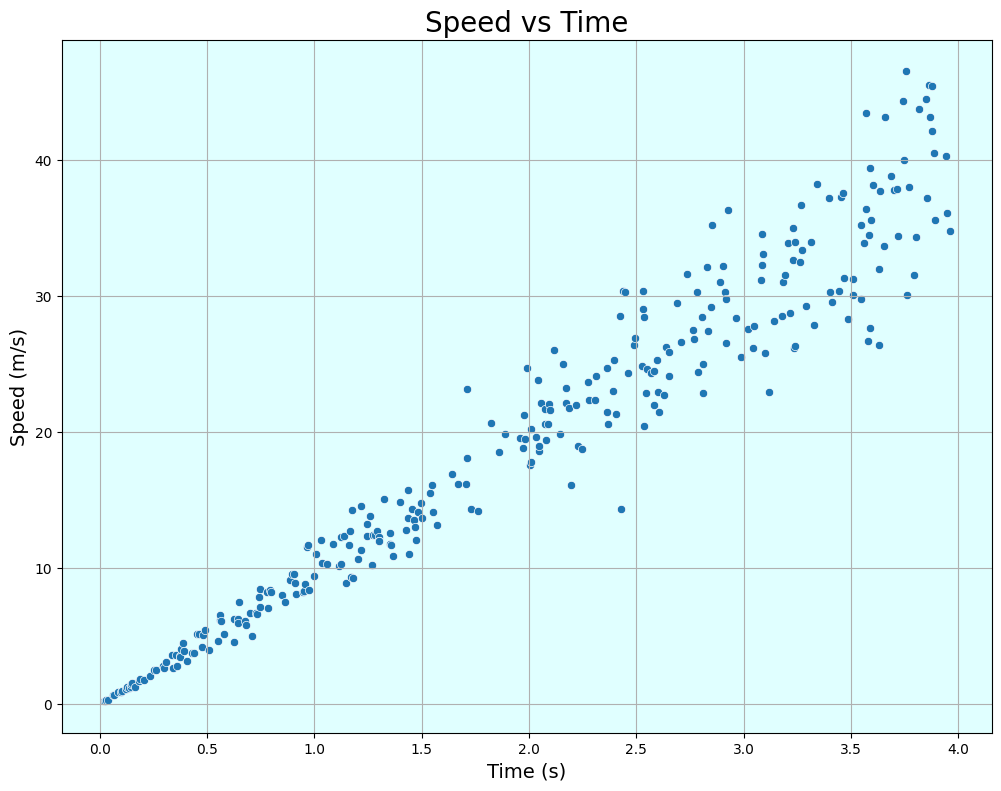

In [ ]:
##=============================================================================================##
## Create a Plot of the Data:                                                                  ##
##=============================================================================================##

# Set the title of the plot:

title = "Speed vs Time"

# Set the x-axis and y-axis labels:

x_label = "Time (s)"
y_label = "Speed (m/s)"

# Create a scatterplot of the feature data vs the target data:

graph_1 = plot_data(X1[x_label], y1[y_label], title, [x_label, y_label])

[Return to Top](#Notebook-Start)

<a name="Least-Squares-Linear-Regression"></a>

---

<font size = 6> <b> 6. Least Squares Linear Regression </b> </font>

---

<font size = 5> <b> 6.1 Introducing Least Squares Linear Regression </b> </font>

One of the most widely used methods for fitting a linear model is [least squares linear regression](#Definition-LSLR). This approach finds the line that best-fits the data by minimizing the sum of squared errors.

<br>

><b>Recall</b>: An <b>error</b> is the difference between the actual target value ($\large y_i$) and the model's predicted value ($\large \hat{y}_i$). When we square each error:
>
> <br>
>
> * Positive and negative errors don't cancel each other out.
>
> <br>
>
> * Larger errors are penalized more than smaller ones.

<br>

In this section, we walk through the least squares algorithm for simple linear regression, where we model the relationship between a single feature variable $\large X$ and a target variable $\large y$.

<center>$\rule$</center>

<font size = 5> <b> 6.2 The Least Squares Linear Regression Algorithm </b> </font>

To compute the best-fit line using [least squares linear regression](#Definition-LSLR), we follow these steps:

<br>

1. <font size = 4><b>Collect the following values for each data point  $\large i = 1, 2, ..., N$:</b></font>

  <br>

  * $\Large X_i$ $\large \parens{\textrm{feature value}}$

  <br>

  * $\Large y_i$ $\large \parens{\textrm{actual target value}}$

  <br>

  * $\Large X_i^2$ $\large \parens{\textrm{square of the feature value}}$

  <br>

  * $\Large X_i \cdot y_i$ $\large \parens{\textrm{product of the feature value and the actual target value}}$

<br>

2. <font size = 4><b>Compute the following totals (sums over all $\large N$ data points):</b></font>

  <br>

  * $\Large A = \sum\limits_{i=1}^{N} X_i$

  <br>

  * $\Large B = \sum\limits_{i=1}^{N} y_i$

  <br>

  * $\Large C = \sum\limits_{i=1}^{N} (X_i^2)$

  <br>

  * $\Large D = \sum\limits_{i=1}^{N} (X_i \cdot y_i)$

<br>

3. <font size = 4><b>Calculate the linear coefficient ($\large c$) of the best-fit line:</b></font>

<br>

<center>
<font size = 5>
$
c = \dsfrac{N \cdot D - A \cdot B}{N \cdot C - A^2}
$
</font>
</center>

<br>

4. <font size = 4><b>Calculate the bias ($\large b$) of the best-fit line:</b></font>

<center>
<font size = 5>
$
b = \dsfrac{1}{N} \spc \parens{B - c \cdot A}
$
</font>
</center>

<br>

With ($\large c$) and ($\large b$) computed, the model makes predictions using the formula:

<br>

<center>
<font size = 5>
$
\hat{y}_i = c \spc X_i + b
$
</font>
</center>

<center>$\rule$</center>

<font size = 5> <b> 6.3 Special Case: Linear Regression Through the Origin </b> </font>

In some cases, we know from context that the target value must be zero when the feature value is zero (the model line should pass through the origin). In such a case, we require that the model's bias is zero ($\large b = 0$) and the model's linear coefficient simplifies to:

<br>

<center>
<font size = 5>
$
c = \dsfrac{D}{C}
$
</font>
</center>

<center>$\rule$</center>

<font size = 5> <b> 6.4 Derivation of the Algorithm </b> </font>

If you're interested in where these formulas come from, check out the [Appendix B](#LSLR-Derivation) section of this notebook, where we walk through the full derivation of the [least squares linear regression](#Definition-LSLR) method.

In [ ]:
##=============================================================================================##
## Function:  least_squares_linear_regression                                                  ##
##                                                                                             ##
## Input(s):  X       - 1D feature (independent variable) data                                 ##
##            y       - 1D Target (dependent variable) data                                    ##
##            bias_on - Boolean (Force zero bias if False; Default: True)                      ##
##                                                                                             ##
## Output(s): coefficient  - Model coefficient (slope of the line)                             ##
##            bias         - Model bias (y-intercept of the line)                              ##
##=============================================================================================##

def least_squares_linear_regression(X, y, bias_on = True):

  ##===========================================================================================##
  ## Create a DataFrame of the X, Y, X*Y and X^2 Data:                                         ##
  ##===========================================================================================##

  # Create a DataFrame to hold the values:

  table_df = pd.DataFrame()

  # Add a column for the X data:

  table_df["x"] = X

  # Add a column for the y data:

  table_df["y"] = y

  # Add a column for the X*y data:

  table_df["xy"] = table_df["x"] * table_df["y"]

  # Add a column for the X*X data:

  table_df["x2"] = table_df["x"] * table_df["x"]

  ##===========================================================================================##
  ## Use the DataFrame to Compute the Sums of the Columns:                                     ##
  ##===========================================================================================##

  # Get the number of rows in the DataFrame:

  N = table_df.index.size

  # Get the Sums of the Columns:

  A = table_df["x"].sum()
  B = table_df["y"].sum()
  C = table_df["x2"].sum()
  D = table_df["xy"].sum()

  ##===========================================================================================##
  ## Use the Least Squares Linear Regression Formula to Compute the Coefficient and Bias:      ##
  ##===========================================================================================##

  # Compute the linear coefficient:

  if (bias_on == True):

    coefficient = (N * D - A * B) / (N * C - A**2)

  else:

    coefficient = D / C

  # Compute the bias:

  if (bias_on == True):

    bias = (1 / N) * (B - coefficient * A)

  else:

    bias = 0

  ##===========================================================================================##
  ## Return the Linear Coefficient and the Bias:                                               ##
  ##===========================================================================================##

  return coefficient, bias

[Return to Top](#Notebook-Start)

<a name="Implementing-LSLR"></a>

---

<font size = 6> <b> 7. Implementing Least Squares Linear Regression </b> </font>

---

<font size = 5> <b> 7.1 To Bias or Not to Bias? That is the Question </b> </font>

Now that we understand how [least squares linear regression](#Definition-LSLR) works, we apply it to our free-fall dataset and see how well it performs. We have two modeling choices:

  <br>

  * <b>Include an bias</b>: We let the algorithm choose the best bias (y-intercept) for the line.

  <br>

  * <b>Force the bias to be 0</b>: We require that the model line must pass through the origin.

<br>

Let's test both versions of the model and compare the results. We'll use Root Mean Squared Error (RMSE) again to evaluate which approach provides a better fit to the data.

In [ ]:
##=============================================================================================##
## Create Two Models (One with Bias and One Without):                                          ##
##=============================================================================================##

# Create a linear model with bias:

model_1_coef, model_1_bias = least_squares_linear_regression(X1, y1)

# Create a linear model without bias:

model_2_coef, model_2_bias = least_squares_linear_regression(X1, y1, bias_on = False)

##=============================================================================================##
## Calculate Models' Loss:                                                                     ##
##=============================================================================================##

# Set the x-axis and y-axis labels:

x_label = "Time (s)"
y_label = "Speed (m/s)"

# Compute the root mean squared error loss for model 1:

model_1_loss = rmse_loss(X1[x_label], y1[y_label], model_1_coef, model_1_bias)

# Compute the root mean squared error loss for model 2:

model_2_loss = rmse_loss(X1[x_label], y1[y_label], model_2_coef, model_2_bias)

##=============================================================================================##
## Display The Results:                                                                        ##
##=============================================================================================##

# Set the model names:

model_list = ["With Bias", "Without Bias"]

# Set the coefficient(s) list:

coef_list = [model_1_coef, model_2_coef]

# Set the bias list:

bias_list = [model_1_bias, model_2_bias]

# Set the loss list:

loss_list = [model_1_loss, model_2_loss]

# Display the results:

display_model(model_list, coef_list, bias_list, loss_list, "Our Results")

,Coefficient(s),Bias(es),Loss
Model,,,
With Bias,9.919,-0.142,2.836
Without Bias,9.866,0.000,2.837


<center>$\rule$</center>

<font size = 5> <b> 7.2 Comparing the Models </b> </font>

Now that we have fit both versions of the model, we can visualize the results by plotting each regression model line along with the original data points. This visual comparison will help us see how closely each model matches the data and where they differe from each other.

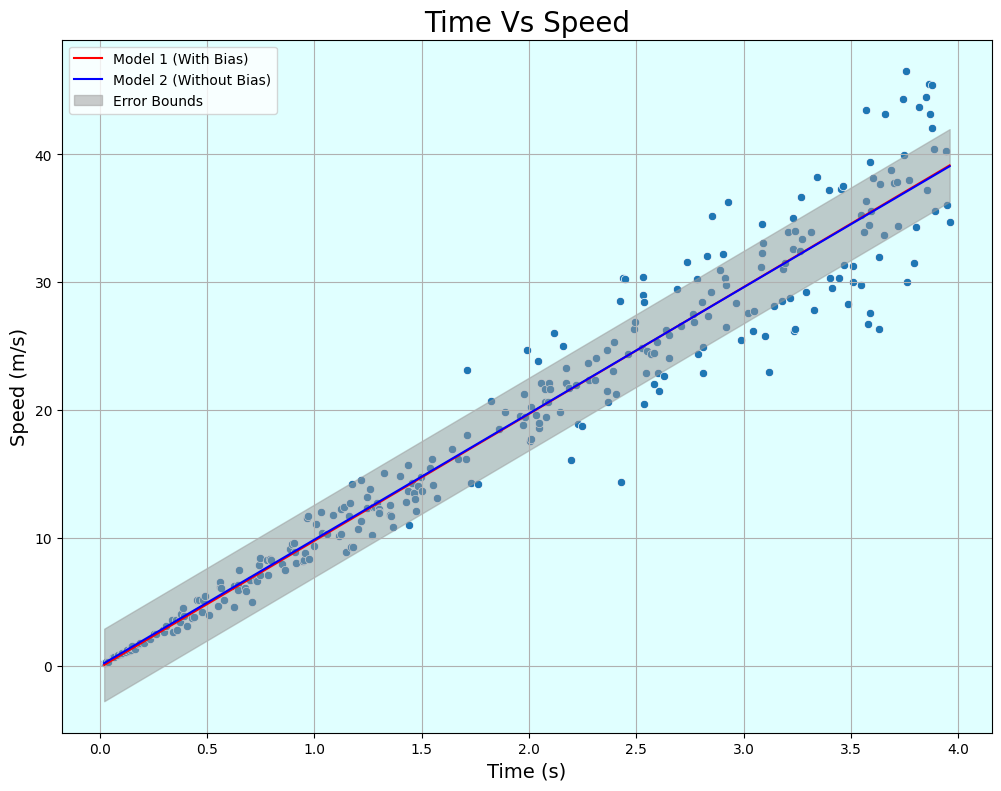

In [ ]:
##=============================================================================================##
## Create Model 1 (With Bias):                                                                 ##
##=============================================================================================##

model_1 = model_1_coef * X1 + model_1_bias

# Set the graph label for model 1:

label_1 = "Model 1 (With Bias)"

# Set the model 1 color:

color_1 = 'red'

##=============================================================================================##
## Create Model 2 (Without Bias):                                                              ##
##=============================================================================================##

model_2 = model_2_coef * X1 + model_2_bias

# Set the graph label for model 2:

label_2 = "Model 2 (Without Bias)"

# Set the model 2 color:

color_2 = 'blue'

##=============================================================================================##
## Create a Plot of the Data and Models:                                                       ##
##=============================================================================================##

# Set the title of the plot:

title = "Time Vs Speed"

# Set the x-axis and y-axis labels:

x_label = "Time (s)"
y_label = "Speed (m/s)"

# Set the feature data vs the target data for the scatterplot:

data = [X1, y1]

# Create the model list:

model_list = [model_1, model_2]

# Set the color list:

color_list = [color_1, color_2]

# Set the label list:

label_list = [label_1, label_2]

# Create a scatterplot of the feature data vs the target data:

graph = plot_data(X1[x_label], y1[y_label], title, [x_label, y_label], model_list, color_list, label_list,
                  error_display = True, error = model_1_loss)

<center>$\rule$</center>

<font size = 5> <b> 7.3 Which Model Should We Choose? </b> </font>

Both models do a good job of fitting the data, but the model that includes an non-zero bias performs slightly better based on RMSE. That said, the physical meaning of the non-bias model is a bit odd. It predicts that at a time of zero seconds, the object should have a speed of <b>(0.142 m/s) upwards!</b> That doesn't make much physical sense, afterall, the object was supposedly released from rest, so its initial speed should be exactly zero.

<br>

This highlihts a key modeling principle: <b>The model that provides the best mathematical fit isn't always the best model!</b> Even if a model slightly outperforms another according to our metrics, it might violate known physical laws or basic logic. A good model isn't just accurate, it also needs to make sense in context. It's always important to combine data-driven insights with common sense.

[Return to Top](#Notebook-Start)

<a name="Introducing-Sklearn-LinearRegression"></a>

---

<font size = 6> <b> 8. Introducing LinearRegression From Scikit-Learn </b> </font>

---

Now that we have seen how linear regression works under the hood, let's simplify our workflow by using one of the most popular tools for building machine learning models in Python: [the scikit-learn library](https://scikit-learn.org/stable/).

<br>

Scikit-learn provides a class called [LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) that handles all the computations for us. It fits a model to the data and makes predictions without requiring us to manually calculate the linear coefficients and bias. Next, we walk through how to use it with our free-fall dataset.

<br>

><b>Note</b>: In this section we also start using scikit-learn's built-in mean_squared_error() function.

In [ ]:
##=============================================================================================##
## Use a LinearRegression Object to Find the Best Fit for the Model:                           ##
##=============================================================================================##

# Create a LinearRegression object without a forced-origin intercept:

model_3 = LinearRegression(fit_intercept = True)

# Create a LinearRegression object with a forced-origin intercept:

model_4 = LinearRegression(fit_intercept = False)

# Fit the LinearRegression objects to the features and target:

model_3.fit(X1, y1)

model_4.fit(X1, y1)

# Get the linear coefficient and bias for model 1:

model_3_coef = model_3.coef_[0][0]
model_3_bias = model_3.intercept_[0]

# Get the linear coefficient and bias for model 2:

model_4_coef = model_4.coef_[0][0]
model_4_bias = model_4.intercept_

##=============================================================================================##
## Get The Models' Predictions:                                                                ##
##=============================================================================================##

model_3_predictions = model_3.predict(X1)

model_4_predictions = model_4.predict(X1)

##=============================================================================================##
## Calculate Models' Loss:                                                                     ##
##=============================================================================================##

model_3_loss = np.sqrt(mean_squared_error(y1, model_3_predictions))

model_4_loss = np.sqrt(mean_squared_error(y1, model_4_predictions))

##=============================================================================================##
## Display The Results:                                                                        ##
##=============================================================================================##

# Set the model names:

model_list = ["Our Model With Bias", "Sklearn Model With Bias",
              "Our Model Without Bias", "Sklearn Model Without Bias"]

# Set the coefficient(s) list:

coef_list = [model_1_coef, model_3_coef, model_2_coef, model_4_coef]

# Set the bias list:

bias_list = [model_1_bias, model_3_bias, model_2_bias, model_4_bias]

# Set the loss list:

loss_list = [model_1_loss, model_3_loss, model_2_loss, model_4_loss]

# Display the results:

display_model(model_list, coef_list, bias_list, loss_list, "Comparing Models")

,Coefficient(s),Bias(es),Loss
Model,,,
Our Model With Bias,9.919,-0.142,2.836
Sklearn Model With Bias,9.919,-0.142,2.836
Our Model Without Bias,9.866,0.000,2.837
Sklearn Model Without Bias,9.866,0.000,2.837


We see that sklearn produces the same slope and intercept we calculated manually earlier. This confirms that our implementation of least squares was correct, and now we can rely on this tool to handle regression more efficiently going forward.

[Return to Top](#Notebook-Start)

<a name="Initial-Velocity-Dataset"></a>

---

<font size = 6> <b> 9. A New Dataset: Now With Initial Velocity </b> </font>

---

<font size = 5> <b> 9.1 What's In The New Dataset? </b> </font>

So far, we have worked with a simplified dataset where objects began falling from rest ($\large v\of{0} = 0 \spc \mps$). In that case, we had a strong physical reason to consider models with zero intercept, even when non-zero bias models provided a better fit to the data.

<br>

Our new dataset is identical in structure to the old one, same columns and units, with one key difference. <b>The objects do not start from rest.</b> Each object begins falling with some initial velocity randomly chosen between $0 \spc \mps$ and $5 \spc \mps$. This change introduces a bias offset in the data. That is, at time ($\large t=0 \spc \textrm{s}$), the objects already have some non-zero speed. This is exactly the kind of situation where allowing the regression model to find a non-zero bias makes physical sense.

In [ ]:
##=============================================================================================##
## Load in the Data Set:                                                                       ##
##=============================================================================================##

# Set the file location:

github = "https://raw.githubusercontent.com/dr-bankert-augustana/PHYS_200/refs/heads/main/"

url = github + "Data/Module_2/freefall_data_2.csv"

# Set the feature list:

feature_list = ["Time (s)"]

# Set the target list:

target_list = ["Speed (m/s)"]

# Load in the data:

X2, y2 = load_model(url, feature_list, target_list)

Full Dataset 
 
 
 
 
 Time (s) 
 Speed (m/s) 
 
 
 
 
 0 
 0.7491 
 10.7690 
 
 
 1 
 1.9014 
 19.0459 
 
 
 2 
 1.4640 
 23.7255 
 
 
 3 
 1.1973 
 13.1807 
 
 
 4 
 0.3120 
 5.8877 
 
 
 
 
 
 
 Feature Data 
 
 
 
 
 Time (s) 
 
 
 
 
 0 
 0.7491 
 
 
 1 
 1.9014 
 
 
 2 
 1.4640 
 
 
 3 
 1.1973 
 
 
 4 
 0.3120 
 
 
 
 
 
 
 Target Data 
 
 
 
 
 Speed (m/s) 
 
 
 
 
 0 
 10.7690 
 
 
 1 
 19.0459 
 
 
 2 
 23.7255 
 
 
 3 
 13.1807 
 
 
 4 
 5.8877

<center> $\rule$ </center>

<font size = 5> <b> 9.2 Visualize The New Dataset </b> </font>

Once again, We create a scatterplot to help us visualize the dataset to observe the patterns and relationships between the variables. In our scatterplot:

  <br>

  * The x-axis data will be : <b>Time (s)</b>

  <br>

  * The y-axis data will be: <b>Speed (m/s)</b>

  <br>

><b>Note</b>: Each point on the graph shows the speed of the object at a specific moment during its fall.

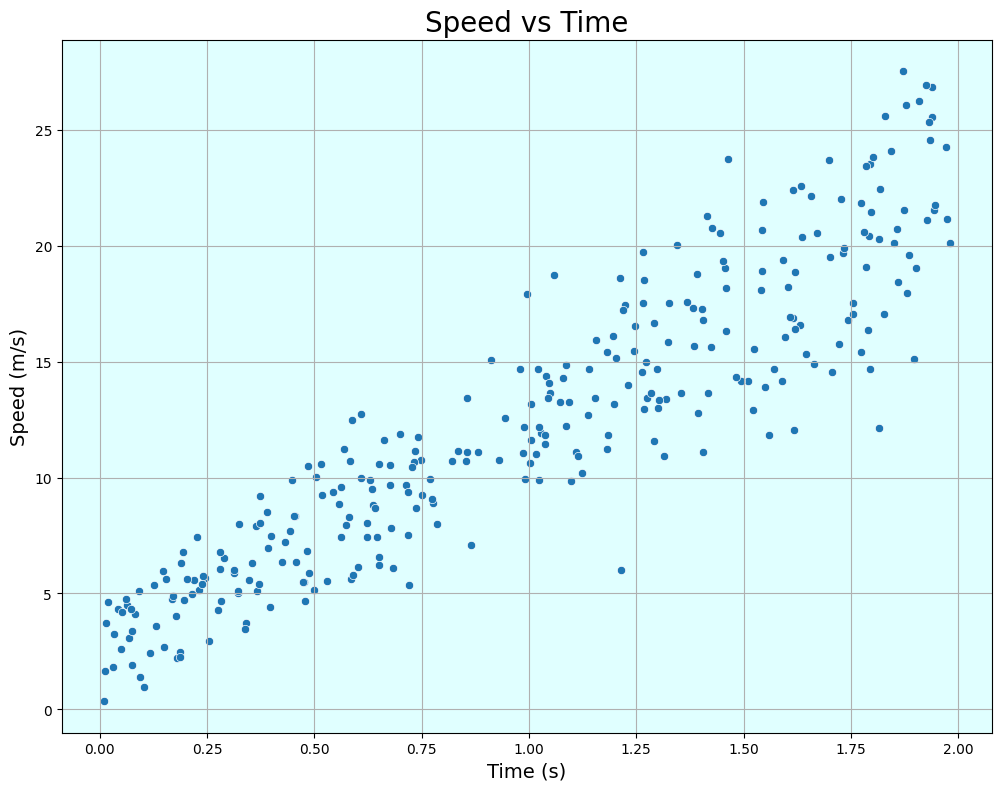

In [ ]:
##=============================================================================================##
## Create a Plot of the Data:                                                                  ##
##=============================================================================================##

# Set the title of the plot:

title = "Speed vs Time"

# Set the x-axis and y-axis labels:

x_label = "Time (s)"
y_label = "Speed (m/s)"

# Create a scatterplot of the feature data vs the target data:

graph = plot_data(X2[x_label], y2[y_label], title, [x_label, y_label])

<center> $\rule$ </center>

<font size = 5> <b> 9.3 Build A Model With Sklearn LinearRegression </b> </font>

Now, we use sklearn's LinearRegression again to find our best-fit model. This time without forcing the bias to zero. Then we can compare our model to the data and see how well we did.

,Coefficient(s),Bias(es),Loss
Model,,,
With Bias,[9.71],[2.71],2.484


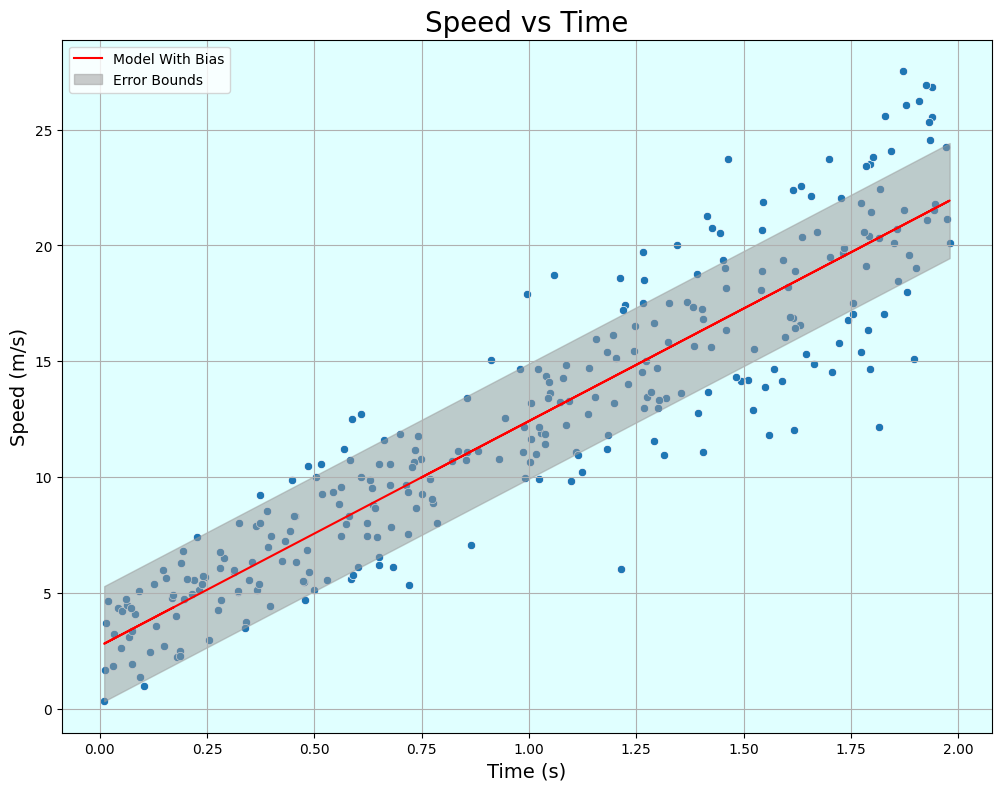

In [ ]:
##=============================================================================================##
## Use a LinearRegression Object to Find the Best Fit for the Model:                           ##
##=============================================================================================##

# Create a LinearRegression object without a forced-origin intercept:

model_5 = LinearRegression(fit_intercept = True)

# Fit the LinearRegression objects to the features and target:

model_5.fit(X2, y2)

# Get the coefficient and bias for model 3:

model_5_coef = np.round(model_5.coef_[0], 2)
model_5_bias = np.round(model_5.intercept_, 2)

##=============================================================================================##
## Get The Model Predictions:                                                                  ##
##=============================================================================================##

model_5_predictions = model_5.predict(X2)

##=============================================================================================##
## Calculate Model Losses:                                                                     ##
##=============================================================================================##

model_5_loss = np.sqrt(mean_squared_error(y2, model_5_predictions))

##=============================================================================================##
## Display The Results:                                                                        ##
##=============================================================================================##

# Set the model names:

model_list = ["With Bias"]

# Set the coefficient(s) list:

coef_list = [model_5_coef]

# Set the bias list:

bias_list = [model_5_bias]

# Set the loss list:

loss_list = [model_5_loss]

# Display the results:

display_model(model_list, coef_list, bias_list, loss_list, "Linear Model With Non-Zero Bias")

##=============================================================================================##
## Create a Plot of the Data:                                                                  ##
##=============================================================================================##

# Set the title of the plot:

title = "Speed vs Time"

# Set the x-axis and y-axis labels:

x_label = "Time (s)"
y_label = "Speed (m/s)"

# Set the model's predictions:

model_5_predictions = model_5.predict(X2)

# Create a scatterplot of the feature data vs the target data:

graph = plot_data(X2[x_label], y2[y_label], title, [x_label, y_label],
                  [pd.DataFrame(model_5_predictions)], ["red"], ["Model With Bias"],
                  error_display = True, error = model_5_loss)

<center> $\rule$ </center>

<font size = 5> <b> 9.4 What Do We Learn From Our Model? </b> </font>

We see that the bias found by `LinearRegression` (2.71 $\mps$) is quite close to the average initial velocity used to generate the data (2.5 $\mps$). This is exactly what we expect: since the objects started with different non-zero speeds, the model correctly captures that offset as part of the best-fit line.

<br>

We also notice that the overall error is higher for this dataset than in our previous example. That makes sense, too. There's more variation in the data now due to the range of initial velocities, which makes the relationship between time and speed slightly less uniform.

<br>

<center> $\rule$ </center>

<font size = 5> <b> 9.5 What's The Big Takeaway? </b> </font>

If we have reason to believe the data contains an offset, like an initial velocity, then allowing the model to calculate a non-zero bias is not just okay, it's appropriate. But if we know from context (as we did earlier) that the system starts from zero, then forcing the line through the origin can lead to a model that better reflects the real-world behavior, even if the fit is slightly worse according to our loss function.

[Return to Top](#Notebook-Start)

<a name="Multivariate-Linear-Regression"></a>

---

<font size = 6> <b> 10. Multivariate Linear Regression </b> </font>

---

<font size = 5> <b> 10.1 Modeling Multiple Features </b> </font>

So far in this lesson, we have focused on simple linear regression, where we modeled the relationship between a target variable and a single feature. But what happens when more than one variable influences the property of a system? That's when we turn to [multivariate linear regression](#Definition-Multi-Linear-Regression) (also known as multiple linear regression). This technique models a target variable as a linear combination of two or more features. It's useful in any situation where the outcome depends on several input variables working together.

<center> $\rule$ </center>

<font size = 5> <b> 10.2 A Physics Example: Perfectly Inelastic Collisions </b> </font>

Let's use a scenario that we've all likely seen in an introductory physics class to explore multivariate regression in action: <b>a perfectly inelastic collision in one dimension</b>. In such a collision, two objects moving with different velocities collide and stick together. The total momentum is conserved, so the final momentum is the sum of the individual momenta:

<br>

<center>
<font size = 5>
$
\vec{p}_f = \vec{p}_1 + \vec{p}_2
$
</font>
</center>

<br>

For this section, we simplify the problem to one dimension. This allows us to treat momentum as a scalar (with sign indicating direction). The conservation equation then becomes:

<br>

<center>
<font size = 5>
$
(m_1 + m_2) \spc v_f = m_1 \spc v_1 + m_2 \spc v_2
$
</font>
</center>

<br>

Solving for the final, post-collision velocity ($\large v_f$), we get:

<br>

<center>
<font size = 5>
$
v_f = \dpfrac{m_1}{m_1 + m_2} \spc v_1 + \dpfrac{m_2}{m_1 + m_2} \spc v_2
$
</font>
</center>

<center> $\rule$ </center>

<font size = 5> <b> 10.3 Connecting to Multivariate Regression </b> </font>

Our final velocity equation has the exact form of a multivariate linear regression model:

<br>

<center>
<font size = 5>
$
v_f = c_1 \spc v_1 + c_2 \spc v_2
$
</font>
</center>

<br>
<br>

<center>
<font size = 5>
$
c_1 = \dpfrac{m_1}{m_1 + m_2} \textrm{,} \hspace{2 pc}
c_2 = \dpfrac{m_2}{m_1 + m_2}
$
</font>
</center>

<br>

  * $\large v_1$ and $\large v_2$ are the model's features (the initial velocities of each object)

  <br>

  * $\large v_f$ is the model's target variable (the final velocity after the collision)

  <br>

  * $\large c_1$ and $\large c_2$ are the model's linear coefficients. These coefficients tell us how much each object's velocity contributes to the final, post-collision velocity of the system.

<br>

<center> $\rule$ </center>

<font size = 5> <b> 10.4 Interpreting the Coefficients </b> </font>

We should highlight two important properties of the coefficients:

  <br>

  1. <b>They sum to 1:</b>

  <br>

<center>
<font size = 5>
$
c_1 + c_2 = \dpfrac{m_1}{m_1 + m_2} + \dpfrac{m_2}{m_1 + m_2} = \dpfrac{m_1 + m_2}{m_1 + m_2} = 1
$
</font>
</center>

  <br>

  2. <b>Their ratio reveals the pre-collision mass ratio:</b>

  <br>

<center>
<font size = 5>
$
\dsfrac{c_1}{c_2} = \dsfrac{m_1}{m_2}
$
</font>
</center>

<br>

Even if we can't know the actual masses of the object's, these coefficients which we can glean from data allow us to infer their relative masses.

<center> $\rule$ </center>

<font size = 5> <b> 10.4 1D Inelastic Collision Dataset </b> </font>

We now move to working with a synthetic dataset that records a series of perfectly inelastic 1D collisions. For each collision, the dataset contains:

  <br>

  * ($\large v_1$): The pre-collision velocity of object 1

  <br>

  * ($\large v_2$): The pre-collision velocity of object 2

  <br>

  * ($\large v_f$): The post-collision velocity of the combined object

<br>

Our task is to build a multivariate linear regression model that predicts the post-collision velocity ($\large v_f$) based on the pre-collision velocities ($\large v_1$) and ($\large v_2$), given that the masses of the objects are unknown to us.

In [ ]:
##=============================================================================================##
## Load in the Data Set:                                                                       ##
##=============================================================================================##

# Set the file location:

github = "https://raw.githubusercontent.com/dr-bankert-augustana/PHYS_200/refs/heads/main/"

url = github + "Data/Module_2/inelastic_collisions_1d.csv"

# Set the feature list:

feature_list = ["v1 (m/s)", "v2 (m/s)"]

# Set the target list:

target_list = ["vf (m/s)"]

# Load in the data:

X3, y3 = load_model(url, feature_list, target_list)

Full Dataset 
 
 
 
 
 v1 (m/s) 
 v2 (m/s) 
 vf (m/s) 
 
 
 
 
 0 
 -2.5092 
 -8.9664 
 -5.3791 
 
 
 1 
 9.0143 
 0.6271 
 5.2866 
 
 
 2 
 4.6399 
 0.8127 
 2.9389 
 
 
 3 
 1.9732 
 2.7486 
 2.3178 
 
 
 4 
 -6.8796 
 4.5218 
 -1.8123 
 
 
 
 
 
 
 Feature Data 
 
 
 
 
 v1 (m/s) 
 v2 (m/s) 
 
 
 
 
 0 
 -2.5092 
 -8.9664 
 
 
 1 
 9.0143 
 0.6271 
 
 
 2 
 4.6399 
 0.8127 
 
 
 3 
 1.9732 
 2.7486 
 
 
 4 
 -6.8796 
 4.5218 
 
 
 
 
 
 
 Target Data 
 
 
 
 
 vf (m/s) 
 
 
 
 
 0 
 -5.3791 
 
 
 1 
 5.2866 
 
 
 2 
 2.9389 
 
 
 3 
 2.3178 
 
 
 4 
 -1.8123

<center> $\rule$ </center>

<font size = 5> <b> 10.5 Modeling The Data With Univariate Regression </b> </font>

Before we jump into using both features together to build our model, let's take a step back and see how well we can do using just one feature at a time. We use scikit-learn's `LinearRegression` model, setting `fit_intercept = False` so that our model is fit <b>without any constant bias term</b>. This is important because (as we know from the physics) the post-collision velocity ($\large v_f$) should be zero if both of the pre-collision velocities are also zero.

<br>

Here's our game plan:

  1. <b>Model 1</b>: Predict the post-collision velocity ($\large v_f$) using only object 1's pre-collision velocity ($\large v_1$) as the feature.

  <br>

  2. <b>Model 2</b>: Predict the post-collision velocity ($\large v_f$) using only object 2's pre-collision velocity ($\large v_2$) as the feature.

  <br>

  3. <b>Evaluate</b>: Measure each model's loss using Root Mean Squared Error (RMSE) to see how well they fit the data.

<br>

Let's see how much predictive power we get from using each feature on its own. In the next section, we use both features together. Comparing the loss values from each type of model will help us anser the question: Is one feature sufficient, or do we need both to get an accurate prediction of the post-collision velocity ($\large v_f$)

In [ ]:
##=============================================================================================##
## Create And Fit The Univariate Regression Models:                                            ##
##=============================================================================================##

model_1 = LinearRegression(fit_intercept = False).fit(X3[['v1 (m/s)']], y3)

model_2 = LinearRegression(fit_intercept = False).fit(X3[['v2 (m/s)']], y3)

##=============================================================================================##
## Get The Model Predictions:                                                                  ##
##=============================================================================================##

model_1_predictions = model_1.predict(X3[['v1 (m/s)']])

model_2_predictions = model_2.predict(X3[['v2 (m/s)']])

##=============================================================================================##
## Calculate Model Losses:                                                                     ##
##=============================================================================================##

model_1_loss = np.sqrt(mean_squared_error(y3, model_1_predictions))

model_2_loss = np.sqrt(mean_squared_error(y3, model_2_predictions))

##=============================================================================================##
## Display The Results:                                                                        ##
##=============================================================================================##

# Set the model names:

model_list = ["v1 only", "v2 only"]

# Set the coefficient(s) list:

coef_list = [model_1.coef_[0][0], model_2.coef_[0][0]]

# Set the bias list:

bias_list = [model_1.intercept_, model_2.intercept_]

# Set the loss list:

loss_list = [model_1_loss, model_2_loss]

# Display the results:

display_model(model_list, coef_list, bias_list, loss_list, "Univariate Regression Models")

,Coefficient(s),Bias(es),Loss
Model,,,
v1 only,0.509,0.0,2.673
v2 only,0.389,0.0,3.248


<center> $\rule$ </center>

<font size = 5> <b> 10.6 Modeling The Data With Multivariate Regression </b> </font>

Now that we've seen the performance of models using each feature individually, let's see what happens when we use both ($\large v_1$) and ($\large v_2$)together to predict the final velocity ($\large v_f$). We once again use scikit-learn's `LinearRegression` class with `fit_intercept = False`, since the physics tells us there should be no constant bias in the model.

<br>

Here's what we do:

  <br>

  1. Create a two-feature DataFrame that contains columns for both $\large v_1$ and $\large v_2$.

  <br>

  2. Use scikit-learn's `LinearRegression` with `fit_intercept = False`.

  <br>

  3. Examine the learned coefficients to see how the model has weighted each feature.

  <br>

  4. Compute the RMSE and compare it to the errors from our single-feature models.

In [ ]:
##=============================================================================================##
## Create And Fit The Univariate Regression Models:                                            ##
##=============================================================================================##

model_3 = LinearRegression(fit_intercept = False).fit(X3, y3)

##=============================================================================================##
## Get The Model Predictions:                                                                  ##
##=============================================================================================##

model_3_predictions = model_3.predict(X3)

##=============================================================================================##
## Calculate Model Losses:                                                                     ##
##=============================================================================================##

model_3_loss = np.sqrt(mean_squared_error(y3, model_3_predictions))

##=============================================================================================##
## Display The Results:                                                                        ##
##=============================================================================================##

# Set the model names:

model_list = ["v1 only", "v2 only", "v1 and v2"]

# Set the coefficient(s) list:

coef_list = [model_1.coef_[0][0], model_2.coef_[0][0], model_3.coef_[0]]

# Set the bias list:

bias_list = [model_1.intercept_, model_2.intercept_, model_3.intercept_]

# Set the loss list:

loss_list = [model_1_loss, model_2_loss, model_3_loss]

# Display the results:

display_model(model_list, coef_list, bias_list, loss_list, "Regression Models")

,Coefficient(s),Bias(es),Loss
Model,,,
v1 only,0.509,0.0,2.673
v2 only,0.389,0.0,3.248
v1 and v2,"[0.556, 0.444]",0.0,0.000


<b>Interpreting the Coefficients:</b>

  * The coefficients sum to 1 (as they should!)
  
  * The ratio of the values is 0.8 (this gives us the mass ratio of the two objects)

In [ ]:
coef_sum = model_3.coef_[0][0] + model_3.coef_[0][1]

print("Sum of the Coefficients:", np.round(coef_sum, 3))

print()

mass_ratio = model_3.coef_[0][1] / model_3.coef_[0][0]

print("Mass Ratio:", np.round(mass_ratio, 3))

Sum of the Coefficients: 1.0

Mass Ratio: 0.8


[Return to Top](#Notebook-Start)

<a name="Multiple-Targets"></a>

---

<font size = 6> <b> 11. Multi-Target Multivariate Linear Regression </b> </font>

---

In [section 10](#Multivariate-Linear-Regression), we introduced [multivariate linear regression](#Definition-Multivariate-Linear-Regression) by exploring perfectly inelastic collisions in one dimension. In this section, we go one step further and allow the collisions to occur in two dimension. To effectively model our system we need to introduce [multi-target multivariate linear regression](#Definition-Multitarget-Multivariate-Linear-Regression).

<br>

Imagine the collisions happening in two dimensions. Each object now has a pre-collision velocity with both an x-component and a y-component. Likewise, the post-collision velocity of the combined objects has the potential to contain both components. Again, we start with the conservation of momentum equation.

<br>

<center>
<font size = 5>
$
\vec{p}_f = \vec{p}_1 + \vec{p}_2
$
</font>
</center>

<br>

Since we are in more than one dimension, we need to treat momentum, and velocity, of each object as a full vector quantity. Replacing $\large \vec{p}$ with $\large m \spc \vec{v}$, the conservation equation then becomes:

<br>

<center>
<font size = 5>
$
(m_1 + m_2) \spc \vec{v}_f = m_1 \spc \vec{v}_1 + m_2 \spc \vec{v}_2
$
</font>
</center>

<br>

Solving for the final, post-collision velocity ($\large \vec{v}_f$), we get:

<br>

<center>
<font size = 5>
$
\twomatrixtall{v_{f,x}}{v_{f,y}} = \dpfrac{m_1}{m_1 + m_2} \spc \twomatrixtall{v_{1,x}}{v_{1,y}} + \dpfrac{m_2}{m_1 + m_2} \spc \twomatrixtall{v_{2,x}}{v_{2,y}}
$
</font>
</center>

<br>

Again, we see that our linear coefficients are given by:

<br>

<center>
<font size = 5>
$
c_1 = \dpfrac{m_1}{m_1 + m_2} \textrm{,} \hspace{2 pc}
c_2 = \dpfrac{m_2}{m_1 + m_2}
$
</font>
</center>

<br>

The big difference between this and our previous work is that now the target is multi-valued.

<br>

<center>
<font size = 5>
$
\vec{v}_f = \twomatrixtall{v_{f,x}}{v_{f,y}}
$
</font>
</center>

<br>

In [ ]:
##=============================================================================================##
## Load in the Data Set:                                                                       ##
##=============================================================================================##

# Set the file location:

github = "https://raw.githubusercontent.com/dr-bankert-augustana/PHYS_200/refs/heads/main/"

url = github + "Data/Module_2/inelastic_collisions_2d.csv"

# Set the feature list:

feature_list = ["v1x (m/s)", "v1y (m/s)", "v2x (m/s)", "v2y (m/s)"]

# Set the target list:

target_list = ['vfx (m/s)', 'vfy (m/s)']

# Load in the data:

X4, y4 = load_model(url, feature_list, target_list)

Full Dataset 
 
 
 
 
 v1x (m/s) 
 v1y (m/s) 
 v2x (m/s) 
 v2y (m/s) 
 vfx (m/s) 
 vfy (m/s) 
 
 
 
 
 0 
 -2.5092 
 -8.9664 
 -6.6213 
 -5.8423 
 -4.1540 
 -7.7167 
 
 
 1 
 9.0143 
 0.6271 
 -4.4282 
 -9.4694 
 3.6373 
 -3.4115 
 
 
 2 
 4.6399 
 0.8127 
 -6.4598 
 -6.3713 
 0.2000 
 -2.0609 
 
 
 3 
 1.9732 
 2.7486 
 -8.2259 
 1.6608 
 -2.1065 
 2.3135 
 
 
 4 
 -6.8796 
 4.5218 
 -7.5873 
 -1.5715 
 -7.1627 
 2.0845 
 
 
 
 
 
 
 Feature Data 
 
 
 
 
 v1x (m/s) 
 v1y (m/s) 
 v2x (m/s) 
 v2y (m/s) 
 
 
 
 
 0 
 -2.5092 
 -8.9664 
 -6.6213 
 -5.8423 
 
 
 1 
 9.0143 
 0.6271 
 -4.4282 
 -9.4694 
 
 
 2 
 4.6399 
 0.8127 
 -6.4598 
 -6.3713 
 
 
 3 
 1.9732 
 2.7486 
 -8.2259 
 1.6608 
 
 
 4 
 -6.8796 
 4.5218 
 -7.5873 
 -1.5715 
 
 
 
 
 
 
 Target Data 
 
 
 
 
 vfx (m/s) 
 vfy (m/s) 
 
 
 
 
 0 
 -4.1540 
 -7.7167 
 
 
 1 
 3.6373 
 -3.4115 
 
 
 2 
 0.2000 
 -2.0609 
 
 
 3 
 -2.1065 
 2.3135 
 
 
 4 
 -7.1627 
 2.0845

In [ ]:
##=============================================================================================##
## Create And Fit The Univariate Regression Models:                                            ##
##=============================================================================================##

model_4 = LinearRegression(fit_intercept = False).fit(X4, y4)

##=============================================================================================##
## Get The Model Predictions:                                                                  ##
##=============================================================================================##

model_4_predictions = model_4.predict(X4)

##=============================================================================================##
## Calculate Model Losses:                                                                     ##
##=============================================================================================##

model_4_loss = np.sqrt(mean_squared_error(y4, model_4_predictions))

##=============================================================================================##
## Display The Results:                                                                        ##
##=============================================================================================##

# Set the model names:

model_list = ["Model 4"]

# Set the coefficient(s) list:

coef_list = [model_4.coef_]

# Set the bias list:

bias_list = [model_4.intercept_]

# Set the loss list:

loss_list = [model_4_loss]

# Display the results:

display_model(model_list, coef_list, bias_list, loss_list, "Linear Models")

,Coefficient(s),Bias(es),Loss
Model,,,
Model 4,"[[0.6, 0.0, 0.4, -0.0], [-0.0, 0.6, 0.0, 0.4]]",0.0,0.0


Interpreting the output:

<br>

$\large v_f = c_1 \spc v_1 + c_2 \spc v_2$

<br>

$\large \twomatrixtall{v_{fx}}{v_{fy}} = \fourmatrixsquare{c_{1 \spc (11)}}{c_{1 \spc (12)}}{c_{1 \spc (21)}}{c_{1 \spc (22)}} \spc \twomatrixtall{v_{1x}}{v_{1y}} + \fourmatrixsquare{c_{2 \spc (11)}}{c_{2 \spc (12)}}{c_{2 \spc (21)}}{c_{2 \spc (22)}} \spc \twomatrixtall{v_{2x}}{v_{2y}}$

<br>

The first list of coefficients are those which inform $v_{fx}$, so that list we see is:

<br>

$\large \brackets{\brackets{\fourmatrixlong{c_{1 \spc (11)}}{c_{1 \spc (12)}}{c_{2 \spc (11)}}{c_{2 \spc (21)}}} \textrm{, } \brackets{\fourmatrixlong{c_{1 \spc (21)}}{c_{1 \spc (22)}}{c_{2 \spc (21)}}{c_{2 \spc (22)}}}}$

<br>

putting that together, we get:

<br>

$\large \twomatrixtall{v_{fx}}{v_{fy}} = \fourmatrixsquare{0.6}{0.0}{0.0}{0.6} \spc \twomatrixtall{v_{1x}}{v_{1y}} + \fourmatrixsquare{0.4}{0.0}{0.0}{0.4} \spc \twomatrixtall{v_{2x}}{v_{2y}}$

<br>

Thus:

<br>


  * $\large c_1 = \fourmatrixsquare{0.6}{0.0}{0.0}{0.6}$

  <br>

  * $\large c_2 = \fourmatrixsquare{0.4}{0.0}{0.0}{0.4}$

<b>Interpreting the Coefficients:</b>

  * The coefficients sum to 1 (as they should!)
  
  * The ratio of the values is 1.5 (this gives us the mass ratio of the two objects)

In [ ]:
coef_sum = model_4.coef_[0][0] + model_4.coef_[0][2]

print("Coefficient Sum:", np.round(coef_sum, 3))

print()

mass_ratio = model_4.coef_[0][0] / model_4.coef_[0][2]

print("Mass Ratio:", np.round(mass_ratio, 3))

Coefficient Sum: 1.0

Mass Ratio: 1.5


[Return to Top](#Notebook-Start)

<a name="Lesson-Summary"></a>

---

<font size = 6> <b> 12. Lesson Summary </b> </font>

---

In this lesson, we explored how linear regression can be used as a powerful tool for building predictive models from data. We started with simple models involving one feature and one target, and gradually extended to more complex scenarios with multiple inputs and outputs. Along the way, we connected the math of regression to real-world physical systems, including free fall and inelastic collisions.

<br>

1. <b>Simple Linear Regression</b>

    We began with models that predict a target variable y using a single feature X.

    The model has the form: y = c X + b

    where c is the slope and b is the intercept (bias).

    We learned to find the best-fit line using the least squares method, which minimizes the sum of squared errors between predictions and actual values.

<br>

2. <b>Interpreting the Bias Term</b>

    We explored when it makes sense to include a non-zero intercept, and when we should force the model through the origin based on physical reasoning (e.g. free fall with zero initial speed).

<br>

3. <b>Using Real Tools: sklearn</b>

    After working through the math manually, we used scikit-learn's LinearRegression class to build models more efficiently and verify our results.

    This reinforced the idea that even when we automate the fitting process, it’s important to understand what the model is doing under the hood.

<br>

4. <b>Multivariate Linear Regression</b>

    We moved to models with multiple input features, where the target variable depends on several variables.

    Example: In a 1D inelastic collision, the final velocity vf​ is a linear combination of both initial velocities v1 and v2​: vf = c1 v1 + c2 v2

<br>

5. <b>Why Multivariate Models Matter</b>

    We saw that using both features in a regression model gives significantly better predictions than using either one alone.

    The learned coefficients can even reveal physical relationships, like the mass ratio of colliding objects.

<br>

6. <b>Multi-Target Regression</b>

    Finally, we extended regression to handle multiple output variables.

    In 2D inelastic collisions, the final velocity has both x and y components, so we used multi-target multivariate linear regression to model both at once.

    Each target dimension is modeled as its own linear combination of inputs.

[Return to Top](#Notebook-Start)

<a name="Appendix-Definitions"></a>

---

<font size = 6> <b> Appendix A: New Term Definitions </b> </font>

---

[Return to Top](#Notebook-Start)

<a name="Appendix-LSLR-Derivation"></a>

---

<font size = 6> <b> Appendix B: Derivation Of Least Squares Linear Regression </b> </font>

---

<font size = 5>
$S = \lsum \spc e^2_i = \lsum \spc \parens{y_i - m \cdot x_i - b}^2$
</font>

<br>

---

<p style='text-align: left;'>
<font size = 5>
\begin{array}{*2>{\displaystyle}l}
& \hspace{100 pc} \\
\parderiv{S}{b} & = \parderiv{}{b} \spc \parens{y_i - m \cdot x_i - b}^2 \\
& = -2 \spc \lsum \parens{y_i - m \cdot x_i - b} = 0 \\
\ra 0 & = \lsum \parens{y_i - m \cdot x_i - b} \\
\ra 0 & = \lsum y_i - m \spc \lsum x_i - N \spc b \\
\ra b & = \dsfrac{1}{N} \parens{\lsum y_i - m \spc \lsum x_i}
\end{array}
</font>
</p>

<br>

---

<font size = 5>
\begin{array}{*2>{\displaystyle}l}
& \hspace{100 pc} \\
\parderiv{S}{m} & = \parderiv{}{m} \spc \parens{y_i - m \cdot x_i - b}^2 \\
& = -2 \spc \lsum \spc x_i \spc \parens{y_i - m \cdot x_i - b} = 0 \\
\ra 0 & = \lsum \spc x_i \spc \parens{y_i - m \cdot x_i - b} \\
\ra 0 & = \lsum x_i \cdot y_i - m \spc \lsum \parens{x_i}^2 - b \spc \lsum x_i\\
\ra 0 & = \lsum x_i \cdot y_i - m \spc \lsum \parens{x_i}^2 - \dsfrac{1}{N} \parens{\lsum y_i - m \spc \lsum x_i} \spc \lsum x_i \\
\ra m & = \dsfrac{N \spc \lsum x_i y_i - \parens{\lsum x_i} \parens{\lsum y_i}}{N \spc \lsum x_i^2 - \parens{\lsum x_i}^2}
\end{array}
</font>

<br>

---

If we artificially enforce a requirement that ($b = 0$):

<font size = 5>
\begin{array}{*2>{\displaystyle}l}
& \hspace{100 pc} \\
m & = \dsfrac{\lsum x_i y_i}{\lsum x_i^2}
\end{array}
</font>

[Return to Top](#Notebook-Start)

---